# Plot one Cifar10 picutre

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torchvision.datasets as datasets

# Load CIFAR-10 dataset
transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Select one image and label
image, label = dataset[0]  # Change index to see different images

# Convert tensor image to NumPy format and display
plt.imshow(image.permute(1, 2, 0))  # Convert (C, H, W) to (H, W, C)
plt.title(f"Label: {dataset.classes[label]}")
plt.axis("off")
plt.show()


# Plot two Channels

Files already downloaded and verified


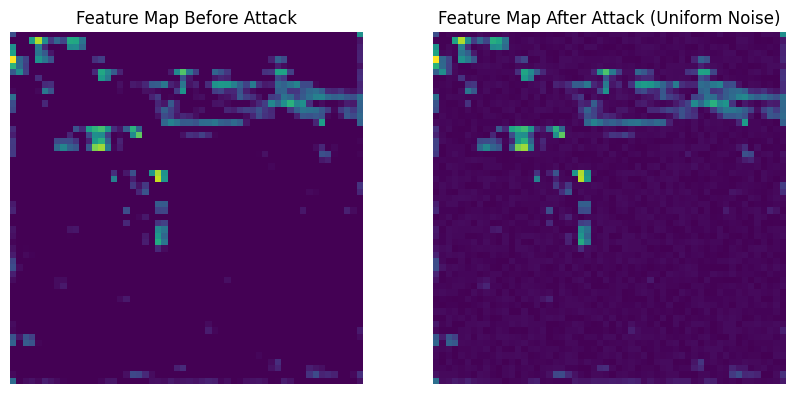

In [5]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
import matplotlib.pyplot as plt

# Set device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define transformation for CIFAR-10 dataset
transform = transforms.Compose([
    transforms.Resize(224),  # Resize to match VGG16 input size
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),  # Normalization for CIFAR-10
])

# Load CIFAR-10 dataset
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=True)

# Load pretrained VGG16 model
model = models.vgg16(pretrained=True).to(device)
model.eval()

# Extract intermediate layers (Conv Layer before Pooling)
class FeatureExtractor(nn.Module):
    def __init__(self, sub_model):
        super(FeatureExtractor, self).__init__()
        self.features = nn.Sequential(*list(sub_model.features[:10]))  # Extracts up to Conv Layer before Pooling

    def forward(self, x):
        return self.features(x)

# Wrap the VGG16 model to extract feature maps
feature_extractor = FeatureExtractor(model).to(device)

# Select a sample image from CIFAR-10 test set
images, labels = next(iter(test_loader))
image = images.to(device)  # Move to GPU if available

# Extract feature map before attack
with torch.no_grad():
    clean_feature_map = feature_extractor(image)

# Apply uniform random noise to feature map
noise = torch.rand_like(clean_feature_map) * 0.2  # Small magnitude uniform noise
perturbed_feature_map = clean_feature_map + noise

# Select a single channel for visualization
channel_idx = 10  # Choose a channel to display
clean_channel = clean_feature_map[0, channel_idx].cpu().numpy()
perturbed_channel = perturbed_feature_map[0, channel_idx].cpu().numpy()

# Plot clean vs. perturbed feature maps
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(clean_channel, cmap='viridis')
axes[0].set_title("Feature Map Before Attack")
axes[0].axis("off")

axes[1].imshow(perturbed_channel, cmap='viridis')
axes[1].set_title("Feature Map After Attack (Uniform Noise)")
axes[1].axis("off")

plt.show()
